# Credit Card Fraud Detection — Data Exploration & Model Training

**Dataset:** MLG-ULB Credit Card Fraud Detection (Kaggle)

This notebook is organized to run top-to-bottom without errors (Kernel → Restart & Run All). It covers: data loading, EDA, a fix for a duplicate-row data leakage issue, baseline modeling, XGBoost hyperparameter experimentation, final model selection, SHAP explainability, and model export.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

df = pd.read_csv(r"C:\Users\DELL\Documents\Creditcard fraud detection\data\creditcard.csv")
print("Shape:", df.shape)
df.head(2)

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0


In [2]:
print(df.dtypes)

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


In [3]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")

Missing values per column:
0 total missing values


## 2. Class Balance

In [4]:
print(df['Class'].value_counts())
print()
print((df['Class'].value_counts(normalize=True) * 100).round(4))

Class
0    284315
1       492
Name: count, dtype: int64

Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64


## 3. Duplicate Rows — Found and Fixed

The raw dataset contains duplicate rows. If left in place, a `train_test_split` can place an exact duplicate of a training row into the test set — the model has effectively already seen that 'unseen' test example, which **inflates evaluation metrics**. We check for this, remove duplicates, and verify the leak is closed before doing anything else.

In [5]:
print("Duplicate rows found:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print()
print("Class balance after dedup:")
print(df['Class'].value_counts())

Duplicate rows found: 1081
Shape after removing duplicates: (283726, 31)

Class balance after dedup:
Class
0    283253
1       473
Name: count, dtype: int64


## 4. Exploratory Data Analysis

In [6]:
min_time, max_time = df['Time'].min(), df['Time'].max()
total_hours = (max_time - min_time) / 3600
print(f"Time span: {total_hours:.2f} hours (~{total_hours/24:.1f} days)")

Time span: 48.00 hours (~2.0 days)


In [7]:
overall_stats = df['Amount'].describe()
legit_amount = df[df['Class'] == 0]['Amount']
fraud_amount = df[df['Class'] == 1]['Amount']

print("=== OVERALL AMOUNT METRICS ===")
print(f"Min:    {overall_stats['min']:.2f}")
print(f"Max:    {overall_stats['max']:.2f}")
print(f"Mean:   {overall_stats['mean']:.2f}")
print(f"Median: {overall_stats['50%']:.2f}")
print(f"StdDev: {overall_stats['std']:.2f}\n")

print("=== LEGITIMATE VS FRAUD AMOUNT ===")
print(f"Legit - Mean:   {legit_amount.mean():.2f}  | Fraud - Mean:   {fraud_amount.mean():.2f}")
print(f"Legit - Median: {legit_amount.median():.2f}  | Fraud - Median: {fraud_amount.median():.2f}")

=== OVERALL AMOUNT METRICS ===
Min:    0.00
Max:    25691.16
Mean:   88.47
Median: 22.00
StdDev: 250.40

=== LEGITIMATE VS FRAUD AMOUNT ===
Legit - Mean:   88.41  | Fraud - Mean:   123.87
Legit - Median: 22.00  | Fraud - Median: 9.82


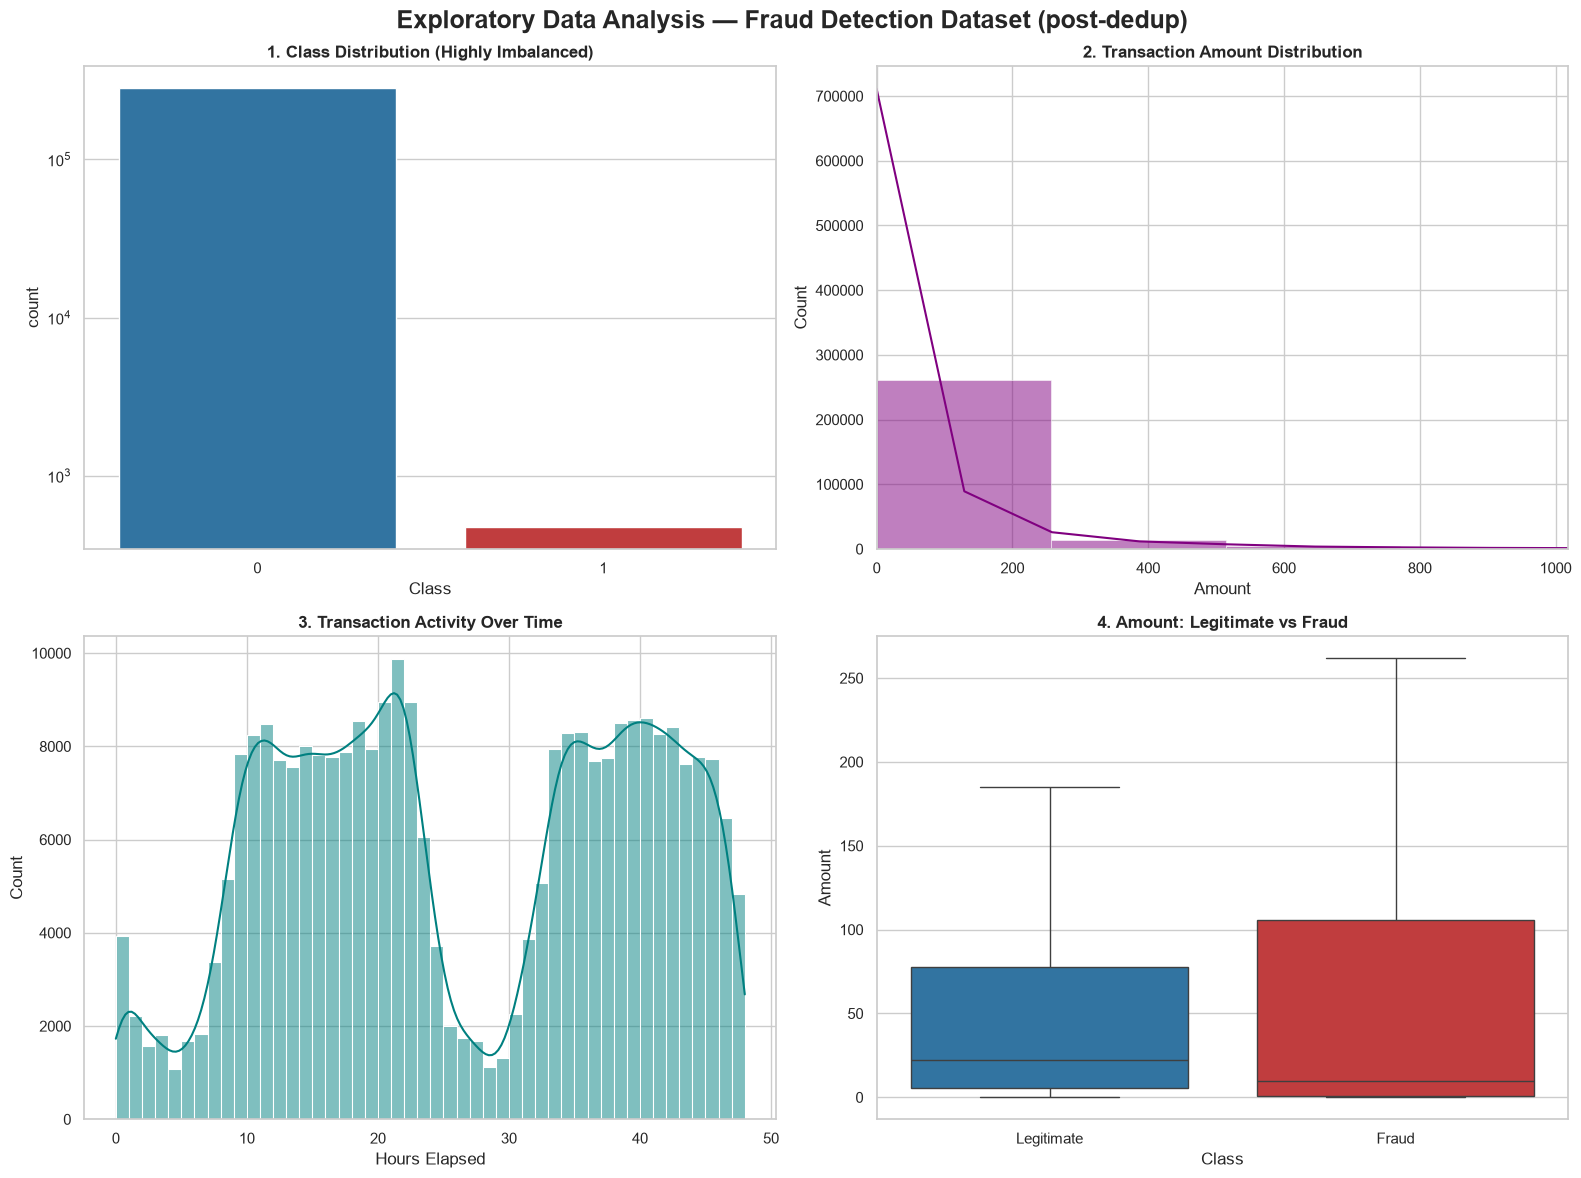

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Exploratory Data Analysis — Fraud Detection Dataset (post-dedup)', fontsize=18, fontweight='bold')

sns.countplot(ax=axes[0, 0], x='Class', data=df, hue='Class', palette=['#1f77b4', '#d62728'], legend=False)
axes[0, 0].set_title('1. Class Distribution (Highly Imbalanced)', fontsize=12, fontweight='bold')
axes[0, 0].set_yscale('log')

sns.histplot(ax=axes[0, 1], data=df, x='Amount', bins=100, kde=True, color='purple')
axes[0, 1].set_title('2. Transaction Amount Distribution', fontsize=12, fontweight='bold')
axes[0, 1].set_xlim(0, df['Amount'].quantile(0.99))

time_hours = df['Time'] / 3600
sns.histplot(ax=axes[1, 0], x=time_hours, bins=48, kde=True, color='teal')
axes[1, 0].set_title('3. Transaction Activity Over Time', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Hours Elapsed')

sns.boxplot(ax=axes[1, 1], data=df, x='Class', y='Amount', hue='Class', palette=['#1f77b4', '#d62728'], showfliers=False, legend=False)
axes[1, 1].set_title('4. Amount: Legitimate vs Fraud', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.show()

In [9]:
v_features = [f'V{i}' for i in range(1, 29)]
correlations = df[v_features].corrwith(df['Class']).abs()
top_pca_features = correlations.sort_values(ascending=False).head(5)

print("=== TOP 5 ANONYMIZED FEATURES CORRELATED WITH FRAUD ===")
for rank, (feature, val) in enumerate(top_pca_features.items(), 1):
    print(f"{rank}. {feature}: Correlation = {val:.4f}")

=== TOP 5 ANONYMIZED FEATURES CORRELATED WITH FRAUD ===
1. V17: Correlation = 0.3135
2. V14: Correlation = 0.2934
3. V12: Correlation = 0.2507
4. V10: Correlation = 0.2070
5. V16: Correlation = 0.1872


### EDA Conclusions

- After removing duplicates, the dataset has **283,726 transactions**: 283,253 legitimate and 473 fraud (~0.167% fraud rate). Accuracy alone is not a suitable evaluation metric.
- No missing values.
- **1,081 duplicate rows were found and removed** prior to splitting, to prevent train/test leakage.
- `Time` spans ~48 hours.
- Fraud transactions have a higher mean amount but lower median than legitimate transactions — amount alone doesn't cleanly separate the classes.
- `V1`–`V28` are anonymized PCA components with no interpretable real-world meaning; correlation with `Class` is informative but is not the same as model feature importance.
- Primary evaluation metric: **PR-AUC / Average Precision**, supported by precision, recall, F1, and ROC-AUC.

## 5. Train/Test Split (post-dedup) + Leakage Verification

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")
print()
print("Train class balance:\n", y_train.value_counts())
print()
print("Test class balance:\n", y_test.value_counts())

Train shape: (226980, 30) | Test shape: (56746, 30)

Train class balance:
 Class
0    226602
1       378
Name: count, dtype: int64

Test class balance:
 Class
0    56651
1       95
Name: count, dtype: int64


In [11]:
# Verify there is no leakage: no exact-duplicate rows shared between train and test
train_full = X_train.copy(); train_full['Class'] = y_train
test_full = X_test.copy(); test_full['Class'] = y_test

overlap = test_full.merge(train_full.drop_duplicates(), how='inner')
print(f"Rows in TEST set that are exact duplicates of a TRAIN row: {len(overlap)}")
assert len(overlap) == 0, "Leakage detected!"
print("No leakage — safe to proceed.")

Rows in TEST set that are exact duplicates of a TRAIN row: 0
No leakage — safe to proceed.


## 6. Feature Scaling

`V1`–`V28` are already PCA-transformed (effectively pre-scaled). Only `Time` and `Amount` need scaling. The scaler is fit **only on the training set** to avoid leaking test-set statistics.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_to_scale = ['Time', 'Amount']

X_train_scaled = X_train.copy()
X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])

X_test_scaled = X_test.copy()
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

print("Scaled Time/Amount — train mean ~0, std ~1:")
print(X_train_scaled[features_to_scale].agg(['mean', 'std']))

Scaled Time/Amount — train mean ~0, std ~1:
              Time        Amount
mean -1.522636e-16  7.487965e-17
std   1.000002e+00  1.000002e+00


## 7. Baseline Model — Logistic Regression

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, classification_report,
                              confusion_matrix, precision_score, recall_score, f1_score)

lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr_model.predict(X_test_scaled)

lr_pr_auc = average_precision_score(y_test, lr_probs)
lr_roc_auc = roc_auc_score(y_test, lr_probs)

print("=== LOGISTIC REGRESSION BASELINE (post-dedup) ===")
print(f"PR-AUC (Average Precision): {lr_pr_auc:.4f}")
print(f"ROC-AUC: {lr_roc_auc:.4f}")
print()
print(classification_report(y_test, lr_preds, target_names=['Legitimate', 'Fraud']))
print("Confusion matrix:\n", confusion_matrix(y_test, lr_preds))

=== LOGISTIC REGRESSION BASELINE (post-dedup) ===
PR-AUC (Average Precision): 0.6719
ROC-AUC: 0.9658

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     56651
       Fraud       0.06      0.87      0.11        95

    accuracy                           0.98     56746
   macro avg       0.53      0.92      0.55     56746
weighted avg       1.00      0.98      0.99     56746

Confusion matrix:
 [[55258  1393]
 [   12    83]]


## 8. XGBoost — `scale_pos_weight` Experimentation

We don't assume the raw `negative/positive` ratio is automatically optimal — we test it directly against half and double that value, and compare PR-AUC.

In [14]:
from xgboost import XGBClassifier

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
base_weight = neg_count / pos_count

weight_options = {'0.5x': base_weight * 0.5, '1.0x': base_weight * 1.0, '2.0x': base_weight * 2.0}
weight_results = {}

print("=== SCALE_POS_WEIGHT SWEEP ===")
for label, w in weight_options.items():
    m = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, subsample=0.8,
                       scale_pos_weight=w, eval_metric='aucpr', random_state=42)
    m.fit(X_train_scaled, y_train)
    probs = m.predict_proba(X_test_scaled)[:, 1]
    pr = average_precision_score(y_test, probs)
    weight_results[label] = {'weight': w, 'pr_auc': pr, 'model': m, 'probs': probs}
    print(f"{label} (weight={w:.2f}) -> PR-AUC: {pr:.4f}")

best_weight_label = max(weight_results, key=lambda k: weight_results[k]['pr_auc'])
print(f"\nBest weight configuration: {best_weight_label}")

=== SCALE_POS_WEIGHT SWEEP ===
0.5x (weight=299.74) -> PR-AUC: 0.8220
1.0x (weight=599.48) -> PR-AUC: 0.8216
2.0x (weight=1198.95) -> PR-AUC: 0.8113

Best weight configuration: 0.5x


## 9. XGBoost — `max_depth` Experimentation

Using the winning weight from above, we test tree depth (model complexity).

In [15]:
winning_weight = weight_results[best_weight_label]['weight']
depth_results = {}

print("=== MAX_DEPTH SWEEP ===")
for depth in [3, 4, 6]:
    m = XGBClassifier(n_estimators=200, max_depth=depth, learning_rate=0.1, subsample=0.8,
                       scale_pos_weight=winning_weight, eval_metric='aucpr', random_state=42)
    m.fit(X_train_scaled, y_train)
    probs = m.predict_proba(X_test_scaled)[:, 1]
    pr = average_precision_score(y_test, probs)
    roc = roc_auc_score(y_test, probs)
    depth_results[depth] = {'pr_auc': pr, 'roc_auc': roc, 'model': m, 'probs': probs}
    print(f"Depth {depth} -> PR-AUC: {pr:.4f}, ROC-AUC: {roc:.4f}")

best_depth = max(depth_results, key=lambda k: depth_results[k]['pr_auc'])
print(f"\nBest depth: {best_depth}")

=== MAX_DEPTH SWEEP ===
Depth 3 -> PR-AUC: 0.8121, ROC-AUC: 0.9729
Depth 4 -> PR-AUC: 0.8220, ROC-AUC: 0.9755
Depth 6 -> PR-AUC: 0.8176, ROC-AUC: 0.9804

Best depth: 4


In [16]:
# Also test a slower learning rate with more trees, for completeness
m_slow = XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8,
                        scale_pos_weight=winning_weight, eval_metric='aucpr', random_state=42)
m_slow.fit(X_train_scaled, y_train)
probs_slow = m_slow.predict_proba(X_test_scaled)[:, 1]
pr_slow = average_precision_score(y_test, probs_slow)
print(f"lr=0.05, n_estimators=400 -> PR-AUC: {pr_slow:.4f}")

print("\n=== FULL COMPARISON TABLE ===")
comparison = pd.DataFrame([
    {'Experiment': 'Logistic Regression', 'PR-AUC': lr_pr_auc},
    {'Experiment': f'XGBoost weight={best_weight_label}, depth=4', 'PR-AUC': weight_results[best_weight_label]['pr_auc']},
    {'Experiment': f'XGBoost depth=3', 'PR-AUC': depth_results[3]['pr_auc']},
    {'Experiment': f'XGBoost depth=4', 'PR-AUC': depth_results[4]['pr_auc']},
    {'Experiment': f'XGBoost depth=6', 'PR-AUC': depth_results[6]['pr_auc']},
    {'Experiment': 'XGBoost lr=0.05/n=400', 'PR-AUC': pr_slow},
])
print(comparison.to_string(index=False))

lr=0.05, n_estimators=400 -> PR-AUC: 0.8093

=== FULL COMPARISON TABLE ===
                  Experiment   PR-AUC
         Logistic Regression 0.671935
XGBoost weight=0.5x, depth=4 0.822009
             XGBoost depth=3 0.812094
             XGBoost depth=4 0.822009
             XGBoost depth=6 0.817557
       XGBoost lr=0.05/n=400 0.809285


## 10. Final Model Selection

In [17]:
final_model = depth_results[best_depth]['model']
final_probs = depth_results[best_depth]['probs']

print(f"Final model: XGBoost, scale_pos_weight={winning_weight:.2f} ({best_weight_label}), max_depth={best_depth}, "
      f"n_estimators=200, learning_rate=0.1, subsample=0.8")
print(f"PR-AUC:  {average_precision_score(y_test, final_probs):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, final_probs):.4f}")

Final model: XGBoost, scale_pos_weight=299.74 (0.5x), max_depth=4, n_estimators=200, learning_rate=0.1, subsample=0.8
PR-AUC:  0.8220
ROC-AUC: 0.9755


## 11. Threshold Analysis (Final Model)

We don't default to 0.5 just because it's the standard cutoff — we look at the precision/recall trade-off across thresholds and choose deliberately.

In [18]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
threshold_rows = []

for t in thresholds:
    preds_t = np.where(final_probs >= t, 1, 0)
    precision = precision_score(y_test, preds_t, zero_division=0)
    recall = recall_score(y_test, preds_t, zero_division=0)
    f1 = f1_score(y_test, preds_t, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_test, preds_t).ravel()
    threshold_rows.append({'Threshold': t, 'Precision': round(precision, 4), 'Recall': round(recall, 4),
                            'F1': round(f1, 4), 'FP': fp, 'FN': fn, 'TP': tp, 'TN': tn})

df_thresholds = pd.DataFrame(threshold_rows)
df_thresholds

,Threshold,Precision,Recall,F1,FP,FN,TP,TN
0,0.10,0.4598,0.8421,0.5948,94,15,80,56557
1,0.20,0.6154,0.8421,0.7111,50,15,80,56601
2,0.30,0.6937,0.8105,0.7476,34,18,77,56617
3,0.40,0.7451,0.8000,0.7716,26,19,76,56625
4,0.50,0.7732,0.7895,0.7812,22,20,75,56629
5,0.60,0.8427,0.7895,0.8152,14,20,75,56637
6,0.70,0.8916,0.7789,0.8315,9,21,74,56642
7,0.80,0.9367,0.7789,0.8506,5,21,74,56646
8,0.90,0.9481,0.7684,0.8488,4,22,73,56647
9,0.95,0.9726,0.7474,0.8452,2,24,71,56649


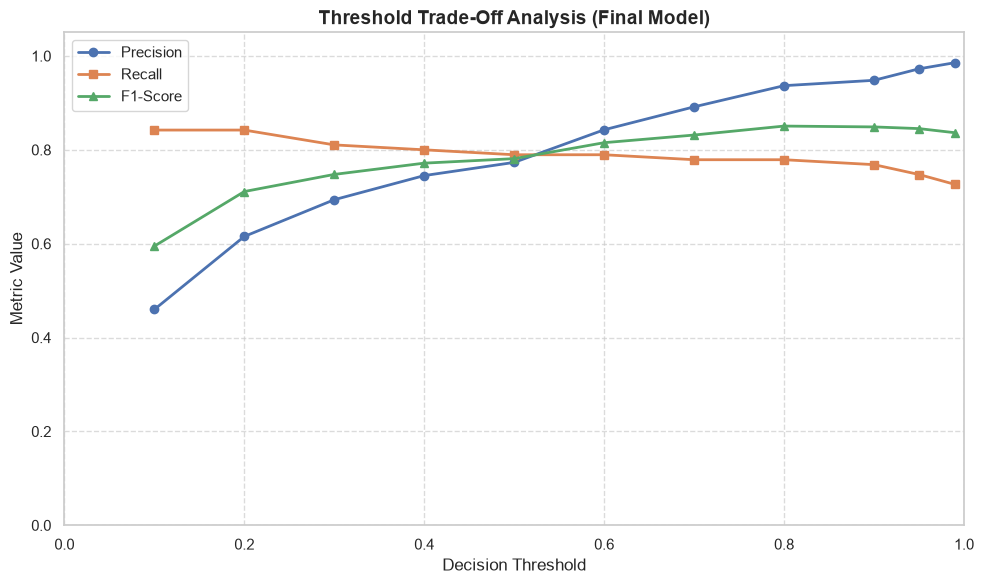

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(df_thresholds['Threshold'], df_thresholds['Precision'], label='Precision', marker='o', linewidth=2)
plt.plot(df_thresholds['Threshold'], df_thresholds['Recall'], label='Recall', marker='s', linewidth=2)
plt.plot(df_thresholds['Threshold'], df_thresholds['F1'], label='F1-Score', marker='^', linewidth=2)
plt.title('Threshold Trade-Off Analysis (Final Model)', fontsize=14, fontweight='bold')
plt.xlabel('Decision Threshold'); plt.ylabel('Metric Value')
plt.xlim(0, 1); plt.ylim(0, 1.05)
plt.legend(); plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout(); plt.show()

**Chosen default threshold:** 0.50 offers a reasonable precision/recall balance for this model — review the table above and adjust this note if you choose differently. The dashboard's slider lets users move away from this default interactively.

## 12. Full Evaluation Report (Final Model @ threshold=0.50)

In [20]:
final_preds_050 = np.where(final_probs >= 0.50, 1, 0)

print("=" * 55)
print("     FINAL MODEL — INDEPENDENT EVALUATION")
print("=" * 55)
print(f"PR-AUC  (primary metric): {average_precision_score(y_test, final_probs):.4f}")
print(f"ROC-AUC:                  {roc_auc_score(y_test, final_probs):.4f}")
print("-" * 55)
print(classification_report(y_test, final_preds_050, target_names=['Legitimate', 'Fraud']))
print("Confusion matrix:")
print(confusion_matrix(y_test, final_preds_050))

     FINAL MODEL — INDEPENDENT EVALUATION
PR-AUC  (primary metric): 0.8220
ROC-AUC:                  0.9755
-------------------------------------------------------
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.77      0.79      0.78        95

    accuracy                           1.00     56746
   macro avg       0.89      0.89      0.89     56746
weighted avg       1.00      1.00      1.00     56746

Confusion matrix:
[[56629    22]
 [   20    75]]


## 13. SHAP Explainability

In [21]:
import shap

explainer = shap.TreeExplainer(final_model)
X_sample = X_test_scaled.head(100)
shap_values = explainer(X_sample)

print("SHAP values computed for", shap_values.shape[0], "sample transactions,", shap_values.shape[1], "features.")

SHAP values computed for 100 sample transactions, 30 features.


In [22]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
shap_importance = pd.DataFrame({
    'Feature': X_sample.columns,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print("=== TOP 10 FEATURES BY MEAN ABSOLUTE SHAP VALUE ===")
print(shap_importance.head(10).to_string(index=False))

=== TOP 10 FEATURES BY MEAN ABSOLUTE SHAP VALUE ===
Feature  Mean |SHAP|
    V14     2.132661
     V4     1.231391
    V12     0.929315
    V11     0.730382
    V10     0.591421
     V3     0.474422
    V19     0.460241
     V8     0.438120
    V26     0.381253
    V22     0.331013


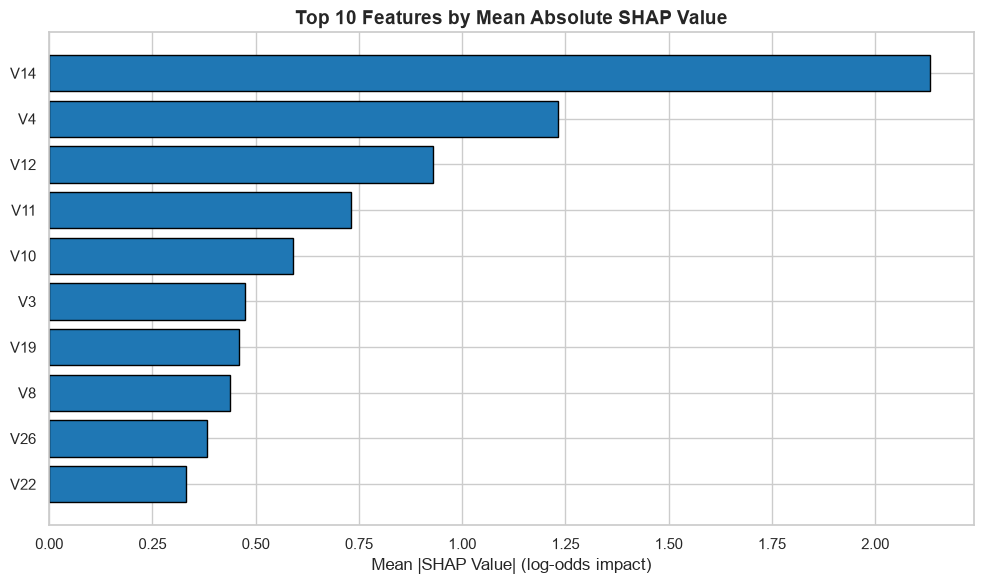

In [23]:
df_plot = shap_importance.head(10).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(df_plot['Feature'], df_plot['Mean |SHAP|'], color='#1f77b4', edgecolor='black')
plt.title('Top 10 Features by Mean Absolute SHAP Value', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP Value| (log-odds impact)')
plt.tight_layout(); plt.show()

### Individual case study: a real fraud transaction

Note: since `V1`–`V28` are anonymized PCA components, we describe their effect only as *"Feature X contributed strongly toward the fraud prediction"* — we do not assign them fabricated real-world meanings like 'unusual location', since that information isn't actually available.

In [24]:
fraud_positions = np.where(y_test.values == 1)[0]
selected_position = fraud_positions[0]
single_row = X_test_scaled.iloc[[selected_position]]

single_shap = explainer(single_row)
fraud_probability = final_model.predict_proba(single_row)[0, 1]

print(f"Selected fraud case — actual class: 1")
print(f"Predicted fraud probability: {fraud_probability*100:.2f}%")

Selected fraud case — actual class: 1
Predicted fraud probability: 99.92%


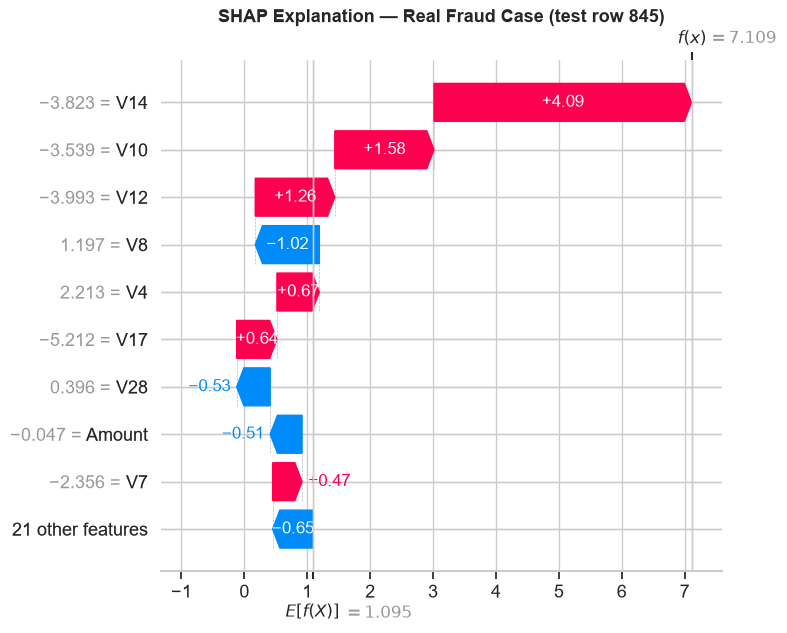

In [25]:
plt.figure(figsize=(12, 6))
shap.plots.waterfall(single_shap[0], max_display=10, show=False)
plt.title(f'SHAP Explanation — Real Fraud Case (test row {selected_position})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Save Model Artifacts

In [26]:
os.makedirs("models", exist_ok=True)

joblib.dump(final_model, "models/final_model.pkl")
joblib.dump(scaler, "models/fraud_scaler.pkl")

print("Saved: models/final_model.pkl")
print("Saved: models/fraud_scaler.pkl")

Saved: models/final_model.pkl
Saved: models/fraud_scaler.pkl


## 15. Reload Validation

Confirms the saved artifacts reproduce identical predictions after being loaded fresh — this is what your FastAPI backend will rely on.

In [27]:
loaded_model = joblib.load("models/final_model.pkl")
loaded_scaler = joblib.load("models/fraud_scaler.pkl")

X_test_reloaded = X_test.copy()
X_test_reloaded[['Time', 'Amount']] = loaded_scaler.transform(X_test[['Time', 'Amount']])
reloaded_probs = loaded_model.predict_proba(X_test_reloaded)[:, 1]

identical = np.allclose(final_probs, reloaded_probs)
print(f"Loaded model produces identical predictions to in-memory model: {identical}")

Loaded model produces identical predictions to in-memory model: True
